In [1]:
import glob
import cv2
import numpy as np
import os 
import matplotlib.pyplot as plt
import matplotlib.patches as patches


In [2]:
imagenes = glob.glob('../calibration/fotos/*.jpeg')
print(f"Se encontraron {len(imagenes)} imagenes")

Se encontraron 20 imagenes


In [64]:
patron = (9,6)
cuadro_cm = 2.24 #tamano de cuadro en cms

objp = np.zeros((patron[0]*patron[1],3), np.float32)
#print(objp)
objp[:, :2] = np.mgrid[0:patron[0], 0:patron[1]].T.reshape(-1, 2) * cuadro_cm

print(objp)



objpoints = []
imgpoints = []

for ruta in imagenes:
    img = cv2.imread(ruta)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    ret, corners = cv2.findChessboardCorners(gray, patron, None)
    
    if ret:
        criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
        corners = cv2.cornerSubPix(gray, corners, (11,11), (-1,-1), criteria)
        objpoints.append(objp)
        imgpoints.append(corners)
        #print(corners)
        print(f"✅ {ruta}")
    else:
        print(f"❌ {ruta}")


[[ 0.    0.    0.  ]
 [ 2.24  0.    0.  ]
 [ 4.48  0.    0.  ]
 [ 6.72  0.    0.  ]
 [ 8.96  0.    0.  ]
 [11.2   0.    0.  ]
 [13.44  0.    0.  ]
 [15.68  0.    0.  ]
 [17.92  0.    0.  ]
 [ 0.    2.24  0.  ]
 [ 2.24  2.24  0.  ]
 [ 4.48  2.24  0.  ]
 [ 6.72  2.24  0.  ]
 [ 8.96  2.24  0.  ]
 [11.2   2.24  0.  ]
 [13.44  2.24  0.  ]
 [15.68  2.24  0.  ]
 [17.92  2.24  0.  ]
 [ 0.    4.48  0.  ]
 [ 2.24  4.48  0.  ]
 [ 4.48  4.48  0.  ]
 [ 6.72  4.48  0.  ]
 [ 8.96  4.48  0.  ]
 [11.2   4.48  0.  ]
 [13.44  4.48  0.  ]
 [15.68  4.48  0.  ]
 [17.92  4.48  0.  ]
 [ 0.    6.72  0.  ]
 [ 2.24  6.72  0.  ]
 [ 4.48  6.72  0.  ]
 [ 6.72  6.72  0.  ]
 [ 8.96  6.72  0.  ]
 [11.2   6.72  0.  ]
 [13.44  6.72  0.  ]
 [15.68  6.72  0.  ]
 [17.92  6.72  0.  ]
 [ 0.    8.96  0.  ]
 [ 2.24  8.96  0.  ]
 [ 4.48  8.96  0.  ]
 [ 6.72  8.96  0.  ]
 [ 8.96  8.96  0.  ]
 [11.2   8.96  0.  ]
 [13.44  8.96  0.  ]
 [15.68  8.96  0.  ]
 [17.92  8.96  0.  ]
 [ 0.   11.2   0.  ]
 [ 2.24 11.2   0.  ]
 [ 4.48 11.2 

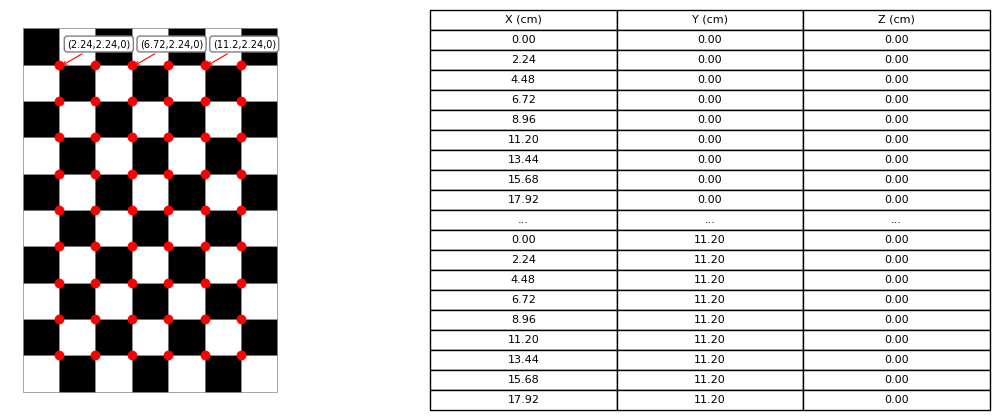

In [70]:

fig = plt.figure(figsize=(14,10))
ax1 = fig.add_axes([0,0,0.20,0.40])
ax2 = fig.add_axes([0.30,0,0.40,0.40])

def MostrarTablero():

    for c in range(6 + 1):
        for r in range(9 + 1):
            x = round((c) * cuadro_cm,2)
            y = round((r) * cuadro_cm,2)
            
            color = 'white' if (c + r) % 2 == 0 else 'black'
            rect = patches.Rectangle((x,y)
                                    , cuadro_cm, cuadro_cm,
                                    linewidth=0.5,
                                    edgecolor='gray',
                                    facecolor=color)
            if r == 1 and c % 2 == 1 :
                ax1.annotate(f"({x},{y},0)",(x,20),(x + .5, y + 19),fontsize=7,arrowprops=dict(arrowstyle='->', color='red', lw=0.8),
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray'))
            ax1.add_patch(rect)
            ax1.axis('off')


    for r in range(9):
        for c in range(6):
            x = (c + 1) * cuadro_cm
            y = (r + 1) * cuadro_cm
            ax1.plot(x, y, 'o', color='red')


def mostrarLista():
    headers = ['X (cm)', 'Y (cm)', 'Z (cm)']
        # Mostrar solo primeras 9 y últimas 9
    indices = list(range(9)) + list(range(45, 54))
    filas = []
    for i in indices:
        filas.append([f'{objp[i][0]:.2f}',
                    f'{objp[i][1]:.2f}', '0.00'])
    # Agregar fila de "..." en el medio
    filas.insert(9, ['...', '...', '...'])

    tabla = ax2.table(
        cellText=filas,
        colLabels=headers,
        loc='center',
        cellLoc='center'
    )
    tabla.auto_set_font_size(False)
    tabla.set_fontsize(8)
    tabla.scale(1, 1.2)  # ajusta alto de filas
    ax2.axis('off')


MostrarTablero()
mostrarLista()

In [72]:
ret, mtx, dist,rvecs, tvecs = cv2.calibrateCamera(objpoints,imgpoints,gray.shape[::-1],None,None)

print("Calibración exitosa:", ret)
print("\nMatriz intrínseca (mtx):")
print(mtx)
print("\nCoeficientes de distorsión (dist):")
print(dist)

Calibración exitosa: 0.46141881065672624

Matriz intrínseca (mtx):
[[1.23415207e+03 0.00000000e+00 7.80616911e+02]
 [0.00000000e+00 1.23163987e+03 4.39901239e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]

Coeficientes de distorsión (dist):
[[ 1.70053710e-01  5.76736515e-01  4.31827659e-03 -3.64784569e-03
  -7.40817749e+00]]


In [73]:
fx = mtx[0][0]
fy = mtx[1][1]
cx = mtx[0][2]
cy = mtx[1][2]

BASE_DIR=os.getcwd()
ruta = os.path.join(BASE_DIR,'..','data','val','video','val.mp4')
print(ruta)

cap = cv2.VideoCapture(ruta)
ancho = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
alto = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
print(f"Resolución real: {ancho}x{alto}")



factor_x = ancho / 1600
factor_y = alto / 900

# Verificar que se mantiene la relacion de ratio
print (ancho / alto)
print (1024 / 576)
print(factor_x)
print(factor_y)


#Escalado de parametros
fx_ajustado = fx * factor_x
fy_ajustado = fy * factor_y
cx_ajustado = cx * factor_x
cy_ajustado = cy * factor_y

print(f"fx: {fx:.2f}")
print(f"fy: {fy:.2f}")
print(f"cx: {cx:.2f}")
print(f"cy: {cy:.2f}")

print("--------------")

print("Parametros ajustados")
print(f"fx: {fx_ajustado:.2f}")
print(f"fy: {fy_ajustado:.2f}")
print(f"cx: {cx_ajustado:.2f}")
print(f"cy: {cy_ajustado:.2f}")



c:\Users\nicoc\Downloads\Tesis NNs\TesisLab\Deteccion-de-vehiculos-y-estimacion-de-distancias-con-YOLOv8\notebook\..\data\val\video\val.mp4
Resolución real: 1920x1080
1.7777777777777777
1.7777777777777777
1.2
1.2
fx: 1234.15
fy: 1231.64
cx: 780.62
cy: 439.90
--------------
Parametros ajustados
fx: 1480.98
fy: 1477.97
cx: 936.74
cy: 527.88


In [23]:
#Guardar archivo
rutaArchivo = os.path.join(BASE_DIR,'..','models','calibracion_camara.npz')
np.savez(rutaArchivo, 
          fx=fx_ajustado, fy=fy_ajustado, 
          cx=cx_ajustado, cy=cy_ajustado)